# 핵심 논문 리뷰와 구현

> 논문을 읽는 이유는 따라하기 위해서가 아니라, **왜 그렇게 했는지 이해하기 위해서다**

LoRA의 코드를 복사하는 것은 누구나 할 수 있다.  
"가중치 변화가 저랭크 구조를 가진다"는 **통찰**을 이해해야 다음 문제를 스스로 풀 수 있다.

---

## 학습 목표

| # | 목표 | 핵심 질문 |
|---|------|----------|
| 1 | **6대 핵심 논문**의 기여를 각각 한 문장으로 요약 | 이 논문이 없었다면 무엇이 불가능했는가? |
| 2 | **Scaling Laws**를 실전 자원 배분에 적용 | 1.5B 모델에 몇 토큰이 최적인가? |
| 3 | **논문 읽기 4단계 방법론** 체득 | 모든 논문을 깊게 읽지 않고 80%를 걸러내는 법은? |
| 4 | 논문의 통찰을 **실전 코드/도구**와 연결 | `from_pretrained`, `get_peft_model`, `DPOTrainer`가 어떤 논문에서 왔는가? |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("Phase 9-03: 핵심 논문 리뷰와 구현")
print("=" * 50)
print("6대 논문의 본질을 파헤치고, 실전과 연결한다")

Phase 9-03: 핵심 논문 리뷰와 구현
6대 논문의 본질을 파헤치고, 실전과 연결한다


---
## 1. 6대 필독 논문 개요

이 6편의 논문은 현대 LLM의 근간을 이루는 핵심 아이디어들이다.  
각 논문이 **어떤 문제를 해결**했고, 학습 로드맵의 **어디에 적용**되었는지를 연결하는 것이 핵심이다.

| # | 논문명 | 연도 | 핵심 기여 | Phase에서 사용한 곳 |
|---|--------|------|----------|-------------------|
| 1 | **Attention Is All You Need** | 2017 | RNN/CNN 없이 Attention만으로 시퀀스 모델링 -- Transformer 탄생 | Phase 2: Transformer 기초 |
| 2 | **LoRA: Low-Rank Adaptation** | 2021 | 전체 가중치 동결 + 저랭크 행렬만 학습 -- 파인튜닝 비용 90% 이상 감소 | Phase 4: LoRA/QLoRA 실전 |
| 3 | **QLoRA** | 2023 | 4-bit 양자화 + LoRA 결합 -- 48GB GPU 1장으로 65B 학습 | Phase 4: 효율적 파인튜닝 |
| 4 | **DPO: Direct Preference Optimization** | 2023 | Reward Model 없이 선호도 직접 학습 -- RLHF 파이프라인 단순화 | Phase 6: 선호도 정렬 |
| 5 | **Scaling Laws for Neural LMs** | 2020 | 모델 크기, 데이터, 연산량의 거듭제곱 법칙 발견 | Phase 9: 자원 배분 전략 |
| 6 | **Chain-of-Thought Prompting** | 2022 | "단계별로 생각하자"로 추론 능력 극대화 | 프롬프트 엔지니어링 전반 |

### 논문에서 실전으로의 연결

| 논문 | 실전 도구 | 코드 1줄 요약 |
|------|----------|-------------|
| Attention Is All You Need | `transformers` | `model = AutoModel.from_pretrained()` |
| LoRA | `peft` | `model = get_peft_model(model, lora_config)` |
| QLoRA | `bitsandbytes` + `peft` | `BitsAndBytesConfig(load_in_4bit=True)` |
| DPO | `trl` | `DPOTrainer(model, ref_model, ...)` |
| Scaling Laws | 설계 원칙 | `tokens = 20 * num_params` |
| Chain-of-Thought | 프롬프트 설계 | `"Let's think step by step"` |

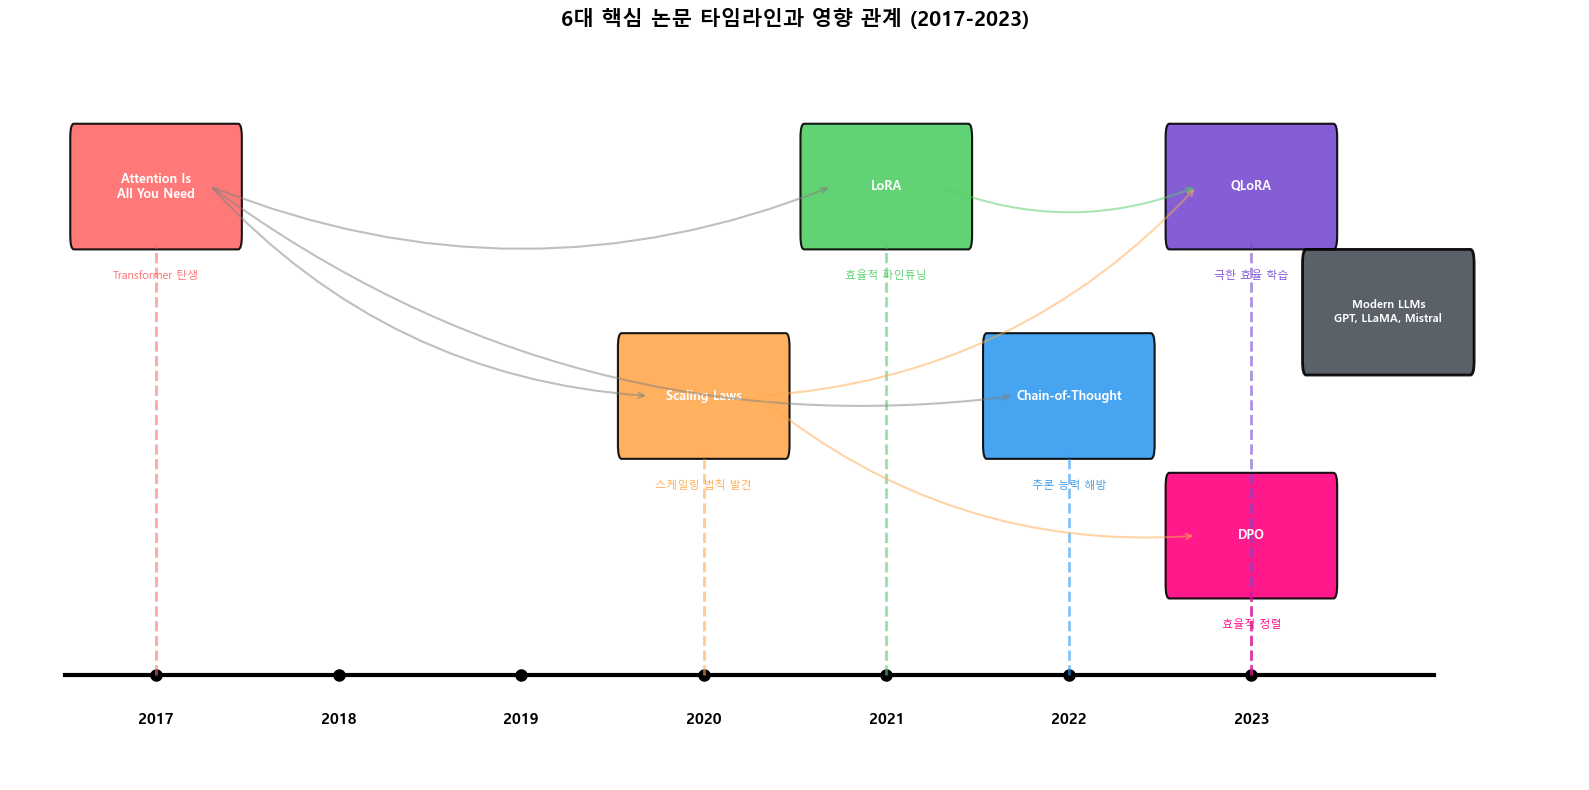


핵심 관찰:
  - Attention Is All You Need (2017)이 모든 것의 시작점
  - 2020-2023 사이에 효율화/정렬/추론 혁신이 집중
  - 각 논문은 독립적이 아니라 이전 논문의 한계를 해결


In [2]:
# === 6대 논문 타임라인 시각화 + 영향 관계 화살표 ===

fig, ax = plt.subplots(figsize=(16, 8))

# 논문 데이터: (연도, y위치, 이름, 색상, 핵심 기여)
papers = [
    (2017, 0.8, 'Attention Is\nAll You Need', '#ff6b6b', 'Transformer 탄생'),
    (2020, 0.5, 'Scaling Laws', '#ffa94d', '스케일링 법칙 발견'),
    (2021, 0.8, 'LoRA', '#51cf66', '효율적 파인튜닝'),
    (2022, 0.5, 'Chain-of-Thought', '#339af0', '추론 능력 해방'),
    (2023, 0.8, 'QLoRA', '#784bd1', '극한 효율 학습'),
    (2023, 0.3, 'DPO', '#ff007f', '효율적 정렬'),
]

# 타임라인 축
ax.plot([2016.5, 2024], [0.1, 0.1], 'k-', linewidth=3, zorder=1)
for year in range(2017, 2024):
    ax.plot(year, 0.1, 'ko', markersize=8, zorder=2)
    ax.text(year, 0.03, str(year), ha='center', fontsize=11, fontweight='bold')

# 논문 박스 배치
box_positions = {}  # 화살표용 위치 저장
for year, y, name, color, contribution in papers:
    # 수직 연결선
    ax.plot([year, year], [0.1, y - 0.08], color=color, linewidth=2, linestyle='--', alpha=0.6)
    
    # 논문 박스
    bbox = FancyBboxPatch((year - 0.45, y - 0.07), 0.9, 0.14,
                          boxstyle="round,pad=0.02", facecolor=color,
                          edgecolor='black', linewidth=1.5, alpha=0.9)
    ax.add_patch(bbox)
    ax.text(year, y, name, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white')
    ax.text(year, y - 0.12, contribution, ha='center', va='top', fontsize=8,
            color=color, fontstyle='italic')
    
    box_positions[name.replace('\n', ' ')] = (year, y)

# 영향 관계 화살표
influence_arrows = [
    ('Attention Is All You Need', 'Scaling Laws', 'gray'),
    ('Attention Is All You Need', 'LoRA', 'gray'),
    ('Attention Is All You Need', 'Chain-of-Thought', 'gray'),
    ('Scaling Laws', 'QLoRA', '#ffa94d'),
    ('LoRA', 'QLoRA', '#51cf66'),
    ('Scaling Laws', 'DPO', '#ffa94d'),
]

for src_name, dst_name, color in influence_arrows:
    src = box_positions[src_name]
    dst = box_positions[dst_name]
    ax.annotate('', xy=(dst[0] - 0.3, dst[1]),
                xytext=(src[0] + 0.3, src[1]),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.5, connectionstyle='arc3,rad=0.2',
                                alpha=0.5))

# 최종 수렴점: "모든 현대 LLM"
final_box = FancyBboxPatch((2023.3, 0.55, ), 0.9, 0.14,
                           boxstyle="round,pad=0.02", facecolor='#495057',
                           edgecolor='black', linewidth=2, alpha=0.9)
ax.add_patch(final_box)
ax.text(2023.75, 0.62, 'Modern LLMs\nGPT, LLaMA, Mistral',
        ha='center', va='center', fontsize=8, fontweight='bold', color='white')

ax.set_xlim(2016.2, 2024.8)
ax.set_ylim(-0.05, 1.0)
ax.axis('off')
ax.set_title('6대 핵심 논문 타임라인과 영향 관계 (2017-2023)',
             fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("\n핵심 관찰:")
print("  - Attention Is All You Need (2017)이 모든 것의 시작점")
print("  - 2020-2023 사이에 효율화/정렬/추론 혁신이 집중")
print("  - 각 논문은 독립적이 아니라 이전 논문의 한계를 해결")

---
## 2. Attention Is All You Need (2017)

### 해결한 문제
RNN은 토큰을 **순차적**으로 처리한다. 100번째 토큰을 처리하려면 99개를 먼저 봐야 한다.  
이것은 물리적 한계가 아니라 **아키텍처의 관성**이었다.

### 핵심 아이디어: Self-Attention
모든 토큰 쌍의 관계를 **한 번에 동시에** 계산한다.

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

| 기호 | 의미 | 직관 |
|------|------|------|
| Q (Query) | "나는 무엇을 찾고 있는가" | 질문 |
| K (Key) | "나는 무엇을 제공하는가" | 라벨 |
| V (Value) | "나의 실제 내용" | 정보 |
| $\sqrt{d_k}$ | 스케일링 | 내적 값이 커지는 것 방지 |

### Multi-Head Attention
단일 Attention은 하나의 관점만 본다.  
**여러 Head**를 병렬로 두면 "문법 관계", "의미 관계", "위치 관계" 등을 동시에 학습한다.

### RNN을 대체한 이유
| 항목 | RNN | Transformer |
|------|-----|-------------|
| 처리 방식 | 순차 (O(n)) | 병렬 (O(1) depth) |
| 장거리 의존성 | gradient vanishing | 직접 연결 |
| GPU 활용 | 비효율 | 완전 병렬화 |
| 확장성 | 한계 명확 | Scaling Laws 발견 가능 |

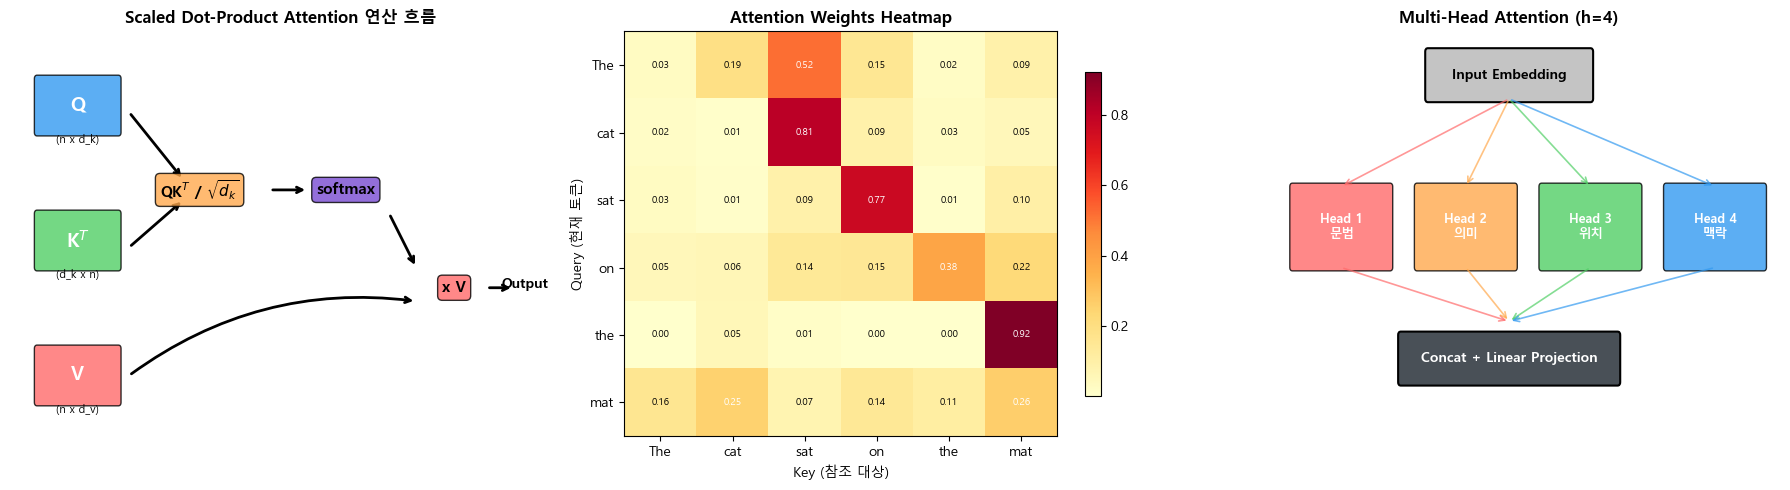


핵심 통찰:
  - Attention은 '모든 토큰이 모든 토큰과 대화'하는 메커니즘
  - sqrt(d_k)로 나누지 않으면 softmax가 극단값으로 수렴 (gradient vanishing)
  - Multi-Head는 같은 데이터를 다른 관점에서 동시에 분석


In [3]:
# === Scaled Dot-Product Attention 수식 시각화 ===
# Q, K, V 행렬 연산 다이어그램 + Attention Weights Heatmap

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Q, K, V 행렬 연산 다이어그램 ---
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('Scaled Dot-Product Attention 연산 흐름', fontsize=12, fontweight='bold')

# 행렬 박스 그리기
boxes = [
    (0.5, 4.5, 'Q', '#339af0', '(n x d_k)'),
    (0.5, 2.5, 'K$^T$', '#51cf66', '(d_k x n)'),
    (0.5, 0.5, 'V', '#ff6b6b', '(n x d_v)'),
]
for x, y, label, color, shape in boxes:
    rect = FancyBboxPatch((x, y), 1.5, 0.8, boxstyle="round,pad=0.05",
                          facecolor=color, alpha=0.8, edgecolor='black')
    ax.add_patch(rect)
    ax.text(x + 0.75, y + 0.4, label, ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')
    ax.text(x + 0.75, y - 0.15, shape, ha='center', fontsize=8)

# 연산 흐름
ax.annotate('', xy=(3.2, 3.8), xytext=(2.2, 4.8),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(3.2, 3.5), xytext=(2.2, 2.8),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(3.5, 3.65, 'QK$^T$ / $\\sqrt{d_k}$', fontsize=11, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='#ffa94d', alpha=0.8))

ax.annotate('', xy=(5.5, 3.65), xytext=(4.8, 3.65),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(6.2, 3.65, 'softmax', fontsize=11, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='#784bd1', alpha=0.8, ec='black'))

ax.annotate('', xy=(7.5, 2.5), xytext=(7.0, 3.3),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(7.5, 2.0), xytext=(2.2, 0.9),
            arrowprops=dict(arrowstyle='->', lw=2, connectionstyle='arc3,rad=-0.2'))
ax.text(8.2, 2.2, 'x V', fontsize=11, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='#ff6b6b', alpha=0.8))

ax.annotate('', xy=(9.3, 2.2), xytext=(8.8, 2.2),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(9.5, 2.2, 'Output', fontsize=10, fontweight='bold', ha='center')

# --- Panel 2: Attention Weights Heatmap 예시 ---
ax2 = axes[1]
np.random.seed(42)
tokens = ['The', 'cat', 'sat', 'on', 'the', 'mat']
n = len(tokens)
d_k = 64

# 시뮬레이션: Q, K 생성 후 attention weights 계산
Q = np.random.randn(n, d_k)
K = np.random.randn(n, d_k)

# 특정 패턴 주입 (cat-sat, the-mat 관계 강화)
Q[1] += K[2] * 0.5   # cat -> sat
Q[4] += K[5] * 0.5   # the -> mat
Q[2] += K[3] * 0.3   # sat -> on

scores = Q @ K.T / np.sqrt(d_k)
# softmax
exp_scores = np.exp(scores - scores.max(axis=-1, keepdims=True))
attn_weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)

im = ax2.imshow(attn_weights, cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(n))
ax2.set_xticklabels(tokens, fontsize=10)
ax2.set_yticks(range(n))
ax2.set_yticklabels(tokens, fontsize=10)
ax2.set_xlabel('Key (참조 대상)', fontsize=10)
ax2.set_ylabel('Query (현재 토큰)', fontsize=10)
ax2.set_title('Attention Weights Heatmap', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax2, shrink=0.8)

# 값 표시
for i in range(n):
    for j in range(n):
        ax2.text(j, i, f'{attn_weights[i, j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='white' if attn_weights[i, j] > 0.25 else 'black')

# --- Panel 3: Multi-Head 개념 ---
ax3 = axes[2]
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 6)
ax3.axis('off')
ax3.set_title('Multi-Head Attention (h=4)', fontsize=12, fontweight='bold')

head_colors = ['#ff6b6b', '#ffa94d', '#51cf66', '#339af0']
head_labels = ['Head 1\n문법', 'Head 2\n의미', 'Head 3\n위치', 'Head 4\n맥락']

# 입력
input_box = FancyBboxPatch((3.5, 5.0), 3, 0.7, boxstyle="round,pad=0.05",
                           facecolor='#c4c4c4', edgecolor='black', linewidth=1.5)
ax3.add_patch(input_box)
ax3.text(5, 5.35, 'Input Embedding', ha='center', va='center',
         fontsize=10, fontweight='bold')

# 각 Head
for i, (color, label) in enumerate(zip(head_colors, head_labels)):
    x = 1.0 + i * 2.3
    rect = FancyBboxPatch((x, 2.5), 1.8, 1.2, boxstyle="round,pad=0.05",
                          facecolor=color, alpha=0.8, edgecolor='black')
    ax3.add_patch(rect)
    ax3.text(x + 0.9, 3.1, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')
    # 입력에서 Head로
    ax3.annotate('', xy=(x + 0.9, 3.7), xytext=(5, 5.0),
                arrowprops=dict(arrowstyle='->', lw=1.2, color=color, alpha=0.7))
    # Head에서 Concat으로
    ax3.annotate('', xy=(5, 1.7), xytext=(x + 0.9, 2.5),
                arrowprops=dict(arrowstyle='->', lw=1.2, color=color, alpha=0.7))

# Concat + Linear
concat_box = FancyBboxPatch((3.0, 0.8), 4, 0.7, boxstyle="round,pad=0.05",
                            facecolor='#495057', edgecolor='black', linewidth=1.5)
ax3.add_patch(concat_box)
ax3.text(5, 1.15, 'Concat + Linear Projection', ha='center', va='center',
         fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("\n핵심 통찰:")
print("  - Attention은 '모든 토큰이 모든 토큰과 대화'하는 메커니즘")
print("  - sqrt(d_k)로 나누지 않으면 softmax가 극단값으로 수렴 (gradient vanishing)")
print("  - Multi-Head는 같은 데이터를 다른 관점에서 동시에 분석")

---
## 3. LoRA (2021) + QLoRA (2023)

### LoRA: Low-Rank Adaptation

**해결한 문제**: 전체 파인튜닝은 모든 파라미터를 업데이트한다. 7B 모델이면 70억 개 전부.  
이것은 물리적 한계가 아니라 **"파인튜닝 = 전체 업데이트"라는 관성**이었다.

**핵심 통찰**: 파인튜닝 시 가중치 변화 $\Delta W$는 **저랭크(low-rank) 구조**를 가진다.

$$W_{new} = W_0 + \Delta W = W_0 + BA$$
- $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times d}$, $r \ll d$
- $W_0$: 동결 (학습 안 함)
- $BA$: 학습 파라미터 = $2 \times d \times r$ (전체의 0.1~1%)

### QLoRA: 극한 효율

| 기법 | 효과 |
|------|------|
| NF4 양자화 | 가중치를 4-bit로 압축 (LLM 가중치 분포에 최적) |
| Double Quantization | 양자화 상수도 양자화 |
| Paged Optimizer | GPU 메모리 초과 시 CPU로 자동 스왑 |

**결과**: 단일 48GB GPU에서 65B 모델 학습 가능

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


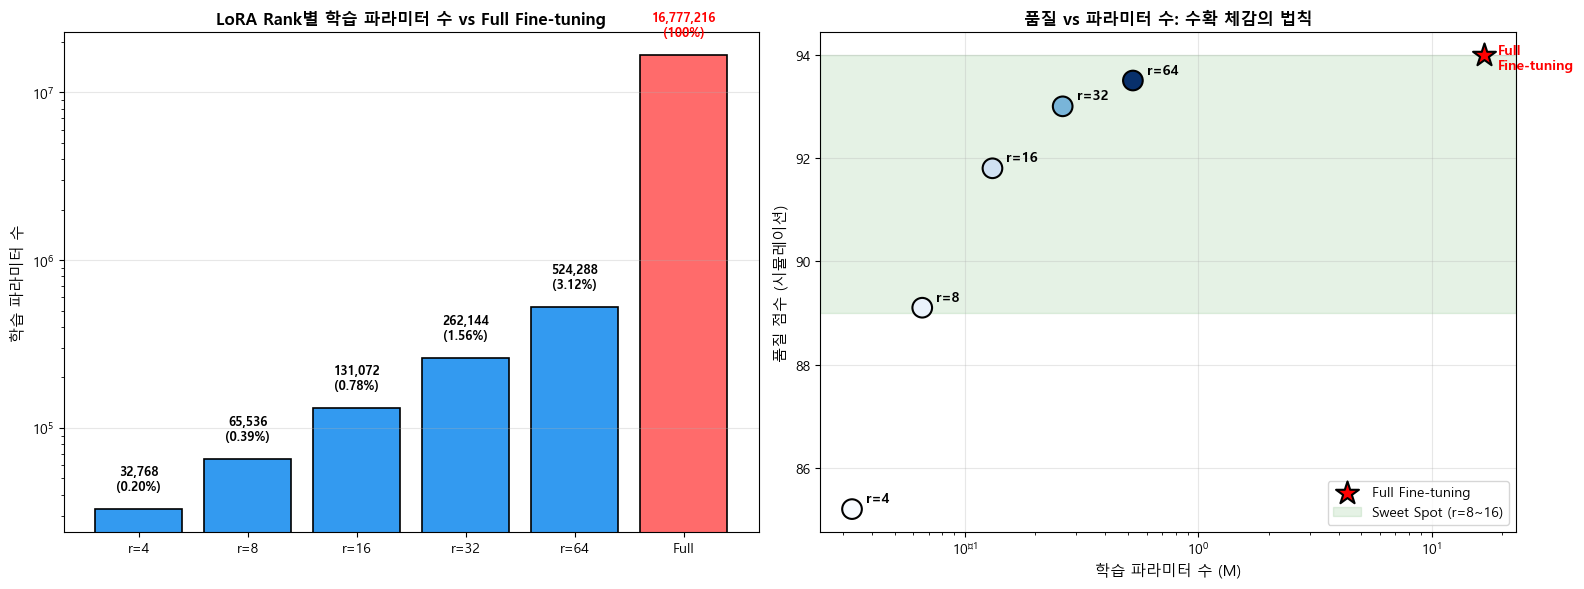


핵심 통찰:
  - d=4096일 때 Full: 16,777,216 파라미터
  - LoRA r=8: 65,536 파라미터 (0.39%)
  - r=8에서 r=64로 8배 늘려도 품질 향상은 ~4%p → 수확 체감
  - r=8~16이 실전 Sweet Spot: 적은 비용으로 Full의 95% 이상 성능


In [4]:
# === LoRA rank에 따른 파라미터 수 비교 ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 모델 설정: d=4096 (7B 모델의 hidden dim 기준)
d = 4096
full_params = d * d  # 전체 파인튜닝 파라미터

ranks = [4, 8, 16, 32, 64]
lora_params = [2 * d * r for r in ranks]
percentages = [p / full_params * 100 for p in lora_params]

# --- Panel 1: 파라미터 수 비교 Bar Chart ---
ax1 = axes[0]
labels = [f'r={r}' for r in ranks] + ['Full']
values = lora_params + [full_params]
colors = ['#339af0'] * len(ranks) + ['#ff6b6b']

bars = ax1.bar(labels, values, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_ylabel('학습 파라미터 수', fontsize=11)
ax1.set_title('LoRA Rank별 학습 파라미터 수 vs Full Fine-tuning', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(axis='y', alpha=0.3)

# 값 표시
for bar, val, pct in zip(bars[:-1], lora_params, percentages):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            f'{val:,.0f}\n({pct:.2f}%)', ha='center', fontsize=9, fontweight='bold')
ax1.text(bars[-1].get_x() + bars[-1].get_width()/2, bars[-1].get_height() * 1.3,
        f'{full_params:,.0f}\n(100%)', ha='center', fontsize=9, fontweight='bold', color='red')

# --- Panel 2: 품질 vs 파라미터 수 Scatter ---
ax2 = axes[1]

# 시뮬레이션 데이터 (실제 논문 결과 추세 반영)
# rank가 증가할수록 품질이 올라가지만 수확 체감
np.random.seed(42)
rank_values = [4, 8, 16, 32, 64]
param_counts = [2 * d * r / 1e6 for r in rank_values]  # 단위: M
# 품질: logarithmic 증가 (수확 체감)
quality_scores = [85.2, 89.1, 91.8, 93.0, 93.5]  # 시뮬레이션
full_quality = 94.0

# LoRA 점들
scatter = ax2.scatter(param_counts, quality_scores, c=rank_values,
                     cmap='Blues', s=200, edgecolors='black',
                     linewidth=1.5, zorder=3)
for r, p, q in zip(rank_values, param_counts, quality_scores):
    ax2.annotate(f'r={r}', (p, q), textcoords='offset points',
               xytext=(10, 5), fontsize=10, fontweight='bold')

# Full fine-tuning 점
full_param_M = full_params / 1e6
ax2.scatter([full_param_M], [full_quality], c='red', s=300, marker='*',
           edgecolors='black', linewidth=1.5, zorder=3, label='Full Fine-tuning')
ax2.annotate('Full\nFine-tuning', (full_param_M, full_quality),
            textcoords='offset points', xytext=(10, -10),
            fontsize=10, fontweight='bold', color='red')

# 효율 영역 강조
ax2.axhspan(89, 94, alpha=0.1, color='green', label='Sweet Spot (r=8~16)')

ax2.set_xlabel('학습 파라미터 수 (M)', fontsize=11)
ax2.set_ylabel('품질 점수 (시뮬레이션)', fontsize=11)
ax2.set_title('품질 vs 파라미터 수: 수확 체감의 법칙', fontsize=12, fontweight='bold')
ax2.set_xscale('log')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n핵심 통찰:")
print(f"  - d={d}일 때 Full: {full_params:,} 파라미터")
print(f"  - LoRA r=8: {2*d*8:,} 파라미터 ({2*d*8/full_params*100:.2f}%)")
print(f"  - r=8에서 r=64로 8배 늘려도 품질 향상은 ~4%p → 수확 체감")
print(f"  - r=8~16이 실전 Sweet Spot: 적은 비용으로 Full의 95% 이상 성능")

---
## 4. DPO (2023) - RLHF 단순화

### 해결한 문제
RLHF는 3단계(SFT -> Reward Model -> PPO)로 복잡하고 불안정하다.  
Reward Model을 별도로 학습하는 것은 물리적 필요가 아니라 **설계의 관성**이었다.

### 핵심 아이디어: Bradley-Terry 모델
인간의 선호를 확률적으로 모델링:

$$p(y_w \succ y_l | x) = \sigma(r(x, y_w) - r(x, y_l))$$

DPO는 이 reward function을 policy에 내재화하여 **단일 손실함수**로 직접 최적화한다:

$$L_{DPO} = -\log \sigma\left(\beta \cdot \left(\log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)\right)$$

| 비교 | RLHF (PPO) | DPO |
|------|-----------|-----|
| 필요 모델 | 3개 (SFT + Reward + Policy) | 2개 (Reference + Policy) |
| 학습 안정성 | 불안정 (HP 민감) | 안정 (분류 손실) |
| 구현 복잡도 | 높음 | 낮음 |
| 실전 성능 | 이론상 우위 | 실전 동등 |

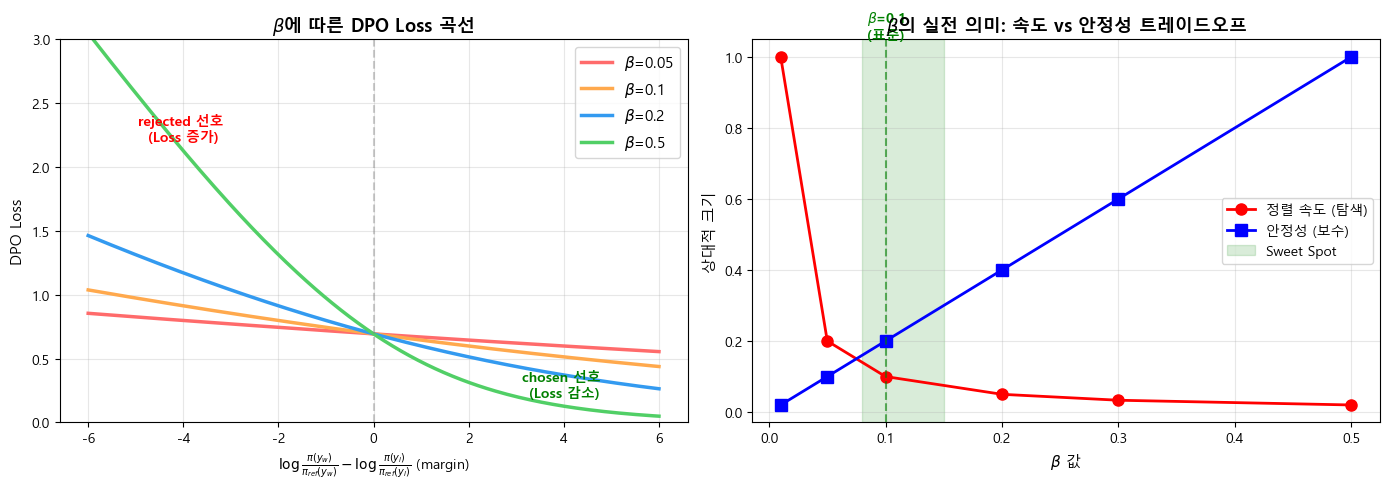

복습 요약 (Phase 6에서 학습한 내용):
  - DPO Loss: chosen의 상대적 확률을 높이고, rejected의 상대적 확률을 낮춘다
  - beta 작음 (0.05): 빠른 정렬, 과적합 위험
  - beta 큼 (0.5):   안전한 정렬, 느린 수렴
  - beta = 0.1:      실전 표준 시작점


In [5]:
# === DPO Loss 시각화 (Phase 6 복습, 간결 버전) ===

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

margins = np.linspace(-6, 6, 200)

# --- Panel 1: beta별 DPO Loss 곡선 ---
betas = [0.05, 0.1, 0.2, 0.5]
colors_beta = ['#ff6b6b', '#ffa94d', '#339af0', '#51cf66']

for beta, color in zip(betas, colors_beta):
    loss = -np.log(sigmoid(beta * margins))
    axes[0].plot(margins, loss, color=color, linewidth=2.5, label=f'$\\beta$={beta}')

axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.4)
axes[0].set_xlabel('$\\log \\frac{\\pi(y_w)}{\\pi_{ref}(y_w)} - \\log \\frac{\\pi(y_l)}{\\pi_{ref}(y_l)}$ (margin)', fontsize=10)
axes[0].set_ylabel('DPO Loss', fontsize=11)
axes[0].set_title('$\\beta$에 따른 DPO Loss 곡선', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 3)
axes[0].grid(True, alpha=0.3)

# 해석 화살표
axes[0].annotate('chosen 선호 \n(Loss 감소)', xy=(4, 0.2), fontsize=10,
                ha='center', color='green', fontweight='bold')
axes[0].annotate('rejected 선호 \n(Loss 증가)', xy=(-4, 2.2), fontsize=10,
                ha='center', color='red', fontweight='bold')

# --- Panel 2: beta의 실전 의미 ---
ax2 = axes[1]
beta_vals = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
exploration = [1/b for b in beta_vals]  # beta가 작을수록 더 많이 탐색
safety = beta_vals  # beta가 클수록 안전

ax2.plot(beta_vals, [e / max(exploration) for e in exploration],
        'r-o', linewidth=2, markersize=8, label='정렬 속도 (탐색)')
ax2.plot(beta_vals, [s / max(safety) for s in safety],
        'b-s', linewidth=2, markersize=8, label='안정성 (보수)')

# Sweet Spot 표시
ax2.axvspan(0.08, 0.15, alpha=0.15, color='green', label='Sweet Spot')
ax2.axvline(x=0.1, color='green', linestyle='--', alpha=0.6)
ax2.text(0.1, 1.05, '$\\beta$=0.1\n(표준)', ha='center', fontsize=10,
        fontweight='bold', color='green')

ax2.set_xlabel('$\\beta$ 값', fontsize=11)
ax2.set_ylabel('상대적 크기', fontsize=11)
ax2.set_title('$\\beta$의 실전 의미: 속도 vs 안정성 트레이드오프', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("복습 요약 (Phase 6에서 학습한 내용):")
print("  - DPO Loss: chosen의 상대적 확률을 높이고, rejected의 상대적 확률을 낮춘다")
print("  - beta 작음 (0.05): 빠른 정렬, 과적합 위험")
print("  - beta 큼 (0.5):   안전한 정렬, 느린 수렴")
print("  - beta = 0.1:      실전 표준 시작점")

---
## 5. Scaling Laws (2020) - Chinchilla Optimal

### 해결한 문제
"모델을 키우면 얼마나 좋아지는가?" "자원을 어디에 써야 하는가?"  
직관과 경험에 의존하던 자원 배분을 **수학적 법칙**으로 바꿨다.

### 핵심 발견: 거듭제곱 법칙

$$L(N) \propto N^{-\alpha_N}, \quad L(D) \propto D^{-\alpha_D}, \quad L(C) \propto C^{-\alpha_C}$$

- $N$: 모델 파라미터 수, $D$: 학습 토큰 수, $C$: 연산량 (FLOPs)
- Loss는 각각의 **거듭제곱 함수**로 감소

### Chinchilla Optimal

$$\text{최적 토큰 수} \approx 20 \times \text{파라미터 수}$$

| 파라미터 수 | 최적 토큰 수 | 실제 사례 |
|------------|------------|----------|
| 1B | 20B 토큰 | 소형 모델 |
| 1.5B | **30B 토큰** | **우리 모델** |
| 7B | 140B 토큰 | LLaMA 2 7B |
| 70B | 1.4T 토큰 | LLaMA 2 70B |

### 자원 배분 의사결정
- 토큰 < 20xN: **데이터를 더 모아라**, 모델 키우지 마라
- 토큰 = 20xN: 균형 상태, 모델 또는 데이터 증가
- 토큰 >> 20xN: **모델을 키워라**, 데이터는 충분

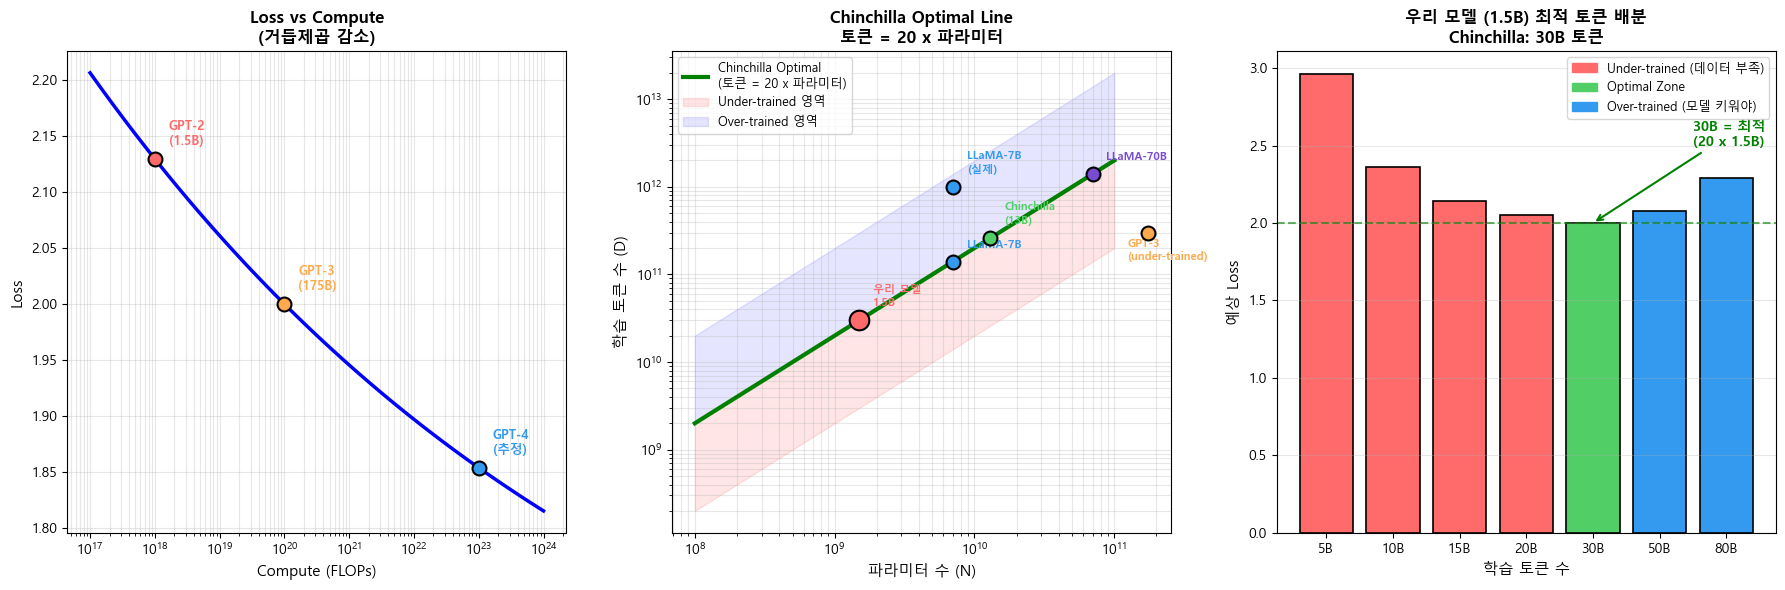


Scaling Laws 핵심:
  - 우리 모델 1.5B의 Chinchilla Optimal: 30B 토큰
  - 토큰이 부족하면 모델 크기를 줄이는 것이 더 효율적
  - GPT-3 (175B)는 300B 토큰으로 학습 → severely under-trained
  - Chinchilla (70B)가 175B보다 적은 파라미터로 더 좋은 성능을 낸 이유


In [6]:
# === Scaling Laws 시각화 (3-Panel) ===

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Panel 1: Loss vs Compute (로그 스케일) ---
ax1 = axes[0]

# 시뮬레이션: L(C) = a * C^(-alpha) + L_inf
compute_flops = np.logspace(17, 24, 100)  # 10^17 ~ 10^24 FLOPs
a_c, alpha_c, L_inf = 5.0, 0.05, 1.5
loss_compute = a_c * (compute_flops ** (-alpha_c)) + L_inf

ax1.plot(compute_flops, loss_compute, 'b-', linewidth=2.5)
ax1.set_xscale('log')
ax1.set_xlabel('Compute (FLOPs)', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Loss vs Compute\n(거듭제곱 감소)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, which='both')

# 주요 모델 위치 표시
model_points = [
    (1e18, 'GPT-2\n(1.5B)', '#ff6b6b'),
    (1e20, 'GPT-3\n(175B)', '#ffa94d'),
    (1e23, 'GPT-4\n(추정)', '#339af0'),
]
for flops, name, color in model_points:
    loss_val = a_c * (flops ** (-alpha_c)) + L_inf
    ax1.scatter([flops], [loss_val], c=color, s=100, edgecolors='black',
              linewidth=1.5, zorder=5)
    ax1.annotate(name, (flops, loss_val), textcoords='offset points',
               xytext=(10, 10), fontsize=9, fontweight='bold', color=color)

ax1.annotate('연산량을 10배 늘려도\nLoss 감소폭은 점점 줄어듦',
            xy=(1e21, 1.75), fontsize=9, fontstyle='italic',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Panel 2: Chinchilla Optimal Line ---
ax2 = axes[1]

params_range = np.logspace(8, 11, 100)  # 100M ~ 100B
chinchilla_tokens = 20 * params_range

ax2.plot(params_range, chinchilla_tokens, 'g-', linewidth=3, label='Chinchilla Optimal\n(토큰 = 20 x 파라미터)')

# 실제 모델들
actual_models = [
    (1.5e9, 30e9, '우리 모델\n1.5B', '#ff6b6b', 200),
    (7e9, 140e9, 'LLaMA-7B', '#339af0', 100),
    (7e9, 1e12, 'LLaMA-7B\n(실제)', '#339af0', 100),
    (13e9, 260e9, 'Chinchilla\n(13B)', '#51cf66', 100),
    (70e9, 1.4e12, 'LLaMA-70B', '#784bd1', 100),
    (175e9, 300e9, 'GPT-3\n(under-trained)', '#ffa94d', 100),
]

for params, tokens, name, color, size in actual_models:
    ax2.scatter([params], [tokens], c=color, s=size, edgecolors='black',
              linewidth=1.5, zorder=5)
    offset = (10, 10) if 'GPT' not in name else (-15, -20)
    ax2.annotate(name, (params, tokens), textcoords='offset points',
               xytext=offset, fontsize=8, fontweight='bold', color=color)

# 영역 표시
ax2.fill_between(params_range, chinchilla_tokens * 0.1, chinchilla_tokens,
                alpha=0.1, color='red', label='Under-trained 영역')
ax2.fill_between(params_range, chinchilla_tokens, chinchilla_tokens * 10,
                alpha=0.1, color='blue', label='Over-trained 영역')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('파라미터 수 (N)', fontsize=11)
ax2.set_ylabel('학습 토큰 수 (D)', fontsize=11)
ax2.set_title('Chinchilla Optimal Line\n토큰 = 20 x 파라미터', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.3, which='both')

# --- Panel 3: 우리 모델 1.5B 위치 + 자원 배분 가이드 ---
ax3 = axes[2]

our_params = 1.5e9
our_optimal_tokens = 20 * our_params  # 30B

token_scenarios = np.array([5, 10, 15, 20, 30, 50, 80]) * 1e9  # 5B ~ 80B
# 시뮬레이션: 최적에 가까울수록 Loss가 낮음
losses = []
for t in token_scenarios:
    ratio = t / our_optimal_tokens
    # U자형 곡선: 최적(ratio=1)에서 가장 낮음
    loss = 2.0 + 0.3 * (np.log(ratio))**2
    losses.append(loss)

colors_bar = []
for t in token_scenarios:
    if t < our_optimal_tokens * 0.8:
        colors_bar.append('#ff6b6b')  # under-trained
    elif t > our_optimal_tokens * 1.5:
        colors_bar.append('#339af0')  # over-trained
    else:
        colors_bar.append('#51cf66')  # optimal

bar_labels = [f'{t/1e9:.0f}B' for t in token_scenarios]
bars = ax3.bar(bar_labels, losses, color=colors_bar, edgecolor='black', linewidth=1.2)

# 최적점 표시
ax3.axhline(y=2.0, color='green', linestyle='--', alpha=0.6, label='Chinchilla Optimal Loss')
ax3.annotate('30B = 최적\n(20 x 1.5B)', xy=(4, 2.0),
            xytext=(5.5, 2.5), fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=1.5, color='green'),
            color='green')

ax3.set_xlabel('학습 토큰 수', fontsize=11)
ax3.set_ylabel('예상 Loss', fontsize=11)
ax3.set_title(f'우리 모델 (1.5B) 최적 토큰 배분\nChinchilla: {our_optimal_tokens/1e9:.0f}B 토큰',
             fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# 범례 (색상 의미)
legend_patches = [
    mpatches.Patch(color='#ff6b6b', label='Under-trained (데이터 부족)'),
    mpatches.Patch(color='#51cf66', label='Optimal Zone'),
    mpatches.Patch(color='#339af0', label='Over-trained (모델 키워야)'),
]
ax3.legend(handles=legend_patches, fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

print("\nScaling Laws 핵심:")
print(f"  - 우리 모델 1.5B의 Chinchilla Optimal: {our_optimal_tokens/1e9:.0f}B 토큰")
print("  - 토큰이 부족하면 모델 크기를 줄이는 것이 더 효율적")
print("  - GPT-3 (175B)는 300B 토큰으로 학습 → severely under-trained")
print("  - Chinchilla (70B)가 175B보다 적은 파라미터로 더 좋은 성능을 낸 이유")

---
## 6. Chain-of-Thought Prompting (2022)

### 해결한 문제
LLM은 복잡한 추론 문제에서 바로 답을 출력하면 틀린다.  
이것은 모델 능력의 한계가 아니라 **"답만 출력하라"는 프롬프트의 관성**이었다.

### 핵심 통찰
> **모델은 이미 추론 능력을 가지고 있다. 꺼내는 방법이 필요할 뿐이다.**

"Let's think step by step" 한 문장으로 GSM8K 정확도: **17.1% -> 58.1%** (PaLM 540B)

### 왜 효과적인가
| 방식 | 과정 | 문제점 |
|------|------|--------|
| Direct | 문제 -> 답 | 중간 과정 건너뜀, 복잡한 문제에서 실패 |
| CoT | 문제 -> 단계1 -> 단계2 -> ... -> 답 | 각 단계가 다음 단계의 맥락 제공 |

CoT의 효과는 **문제 복잡도가 높을수록** 극적으로 증가한다.  
간단한 문제에서는 Direct와 차이가 거의 없다.

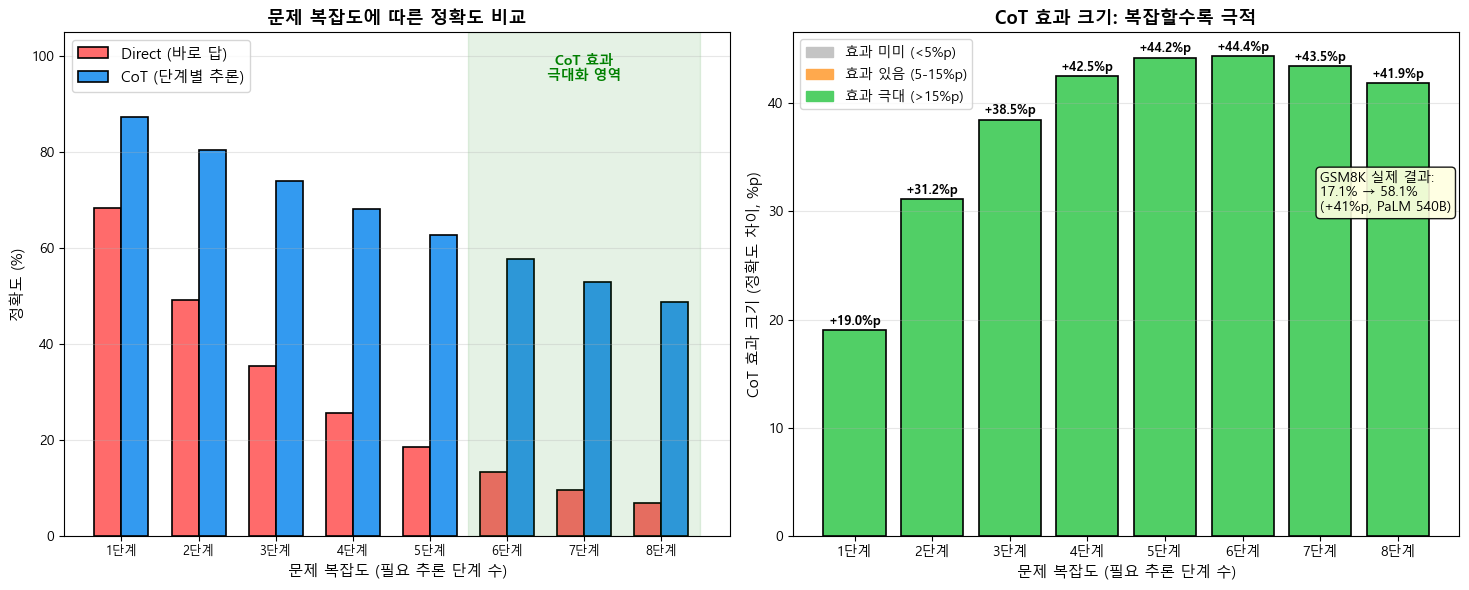


핵심 통찰:
  - 1-2단계 문제: CoT 불필요 (오히려 토큰 낭비)
  - 5단계 이상: CoT 없이는 사실상 정확한 답 불가능
  - 핵심은 '더 많이 생각하게'가 아니라 '구조화해서 생각하게' 하는 것
  - 이것이 o1, o3 등 Reasoning 모델의 기반 아이디어


In [8]:
# === CoT vs Direct 비교 시뮬레이션 ===

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 문제 복잡도 (추론 단계 수)
complexity = np.array([1, 2, 3, 4, 5, 6, 7, 8])
complexity_labels = ['1단계', '2단계', '3단계', '4단계', '5단계', '6단계', '7단계', '8단계']

# 시뮬레이션: Direct는 복잡도 증가 시 급격히 감소, CoT는 완만히 감소
# Direct: 각 단계에서 p=0.7 확률로 맞추면 전체 정확도 = 0.7^n
direct_accuracy = 95 * (0.72 ** complexity)  # 급격 감소
# CoT: 각 단계를 명시적으로 풀면 p=0.92 → 전체 = 0.92^n
cot_accuracy = 95 * (0.92 ** complexity)     # 완만 감소

# --- Panel 1: 복잡도별 Accuracy ---
ax1 = axes[0]
x = np.arange(len(complexity))
width = 0.35

bars1 = ax1.bar(x - width/2, direct_accuracy, width, label='Direct (바로 답)',
               color='#ff6b6b', edgecolor='black', linewidth=1.2)
bars2 = ax1.bar(x + width/2, cot_accuracy, width, label='CoT (단계별 추론)',
               color='#339af0', edgecolor='black', linewidth=1.2)

ax1.set_xlabel('문제 복잡도 (필요 추론 단계 수)', fontsize=11)
ax1.set_ylabel('정확도 (%)', fontsize=11)
ax1.set_title('문제 복잡도에 따른 정확도 비교', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(complexity_labels, fontsize=9)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 105)

# 핵심 영역 강조
ax1.axvspan(4.5, 7.5, alpha=0.1, color='green')
ax1.text(6, 95, 'CoT 효과\n극대화 영역', ha='center', fontsize=10,
        fontweight='bold', color='green')

# --- Panel 2: CoT 효과 크기 (정확도 차이) ---
ax2 = axes[1]
effect_size = cot_accuracy - direct_accuracy

colors_effect = ['#51cf66' if e > 15 else '#ffa94d' if e > 5 else '#c4c4c4'
                for e in effect_size]

bars = ax2.bar(complexity_labels, effect_size, color=colors_effect,
              edgecolor='black', linewidth=1.2)

# 값 표시
for bar, val in zip(bars, effect_size):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'+{val:.1f}%p', ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('문제 복잡도 (필요 추론 단계 수)', fontsize=11)
ax2.set_ylabel('CoT 효과 크기 (정확도 차이, %p)', fontsize=11)
ax2.set_title('CoT 효과 크기: 복잡할수록 극적', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 범례
legend_patches = [
    mpatches.Patch(color='#c4c4c4', label='효과 미미 (<5%p)'),
    mpatches.Patch(color='#ffa94d', label='효과 있음 (5-15%p)'),
    mpatches.Patch(color='#51cf66', label='효과 극대 (>15%p)'),
]
ax2.legend(handles=legend_patches, fontsize=10)

# 실제 논문 결과 주석
ax2.annotate('GSM8K 실제 결과:\n17.1% → 58.1%\n(+41%p, PaLM 540B)',
            xy=(6, 30), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black'))

plt.tight_layout()
plt.show()

print("\n핵심 통찰:")
print("  - 1-2단계 문제: CoT 불필요 (오히려 토큰 낭비)")
print("  - 5단계 이상: CoT 없이는 사실상 정확한 답 불가능")
print("  - 핵심은 '더 많이 생각하게'가 아니라 '구조화해서 생각하게' 하는 것")
print("  - 이것이 o1, o3 등 Reasoning 모델의 기반 아이디어")

---
## 7. 논문 읽기 방법론

논문을 처음부터 끝까지 순서대로 읽는 것은 **가장 비효율적인 방법**이다.

### 4단계 방법론

| 단계 | 시간 | 목표 | 읽는 곳 | 핵심 질문 |
|------|------|------|---------|----------|
| **1. Survey** | 10분 | 이 논문이 나에게 필요한가? | Abstract + Conclusion + Figure/Table만 | "무엇을 해결하고, 결과가 어떤가?" |
| **2. Comprehension** | 1시간 | 핵심 아이디어 이해 | Introduction + Method 개요 + 실험 결과 | "왜 이 방법을 선택했는가?" |
| **3. Analysis** | 2-3시간 | 수식과 실험 깊이 이해 | 수식 유도 + Ablation Study + Appendix | "이 가정이 깨지면 어떻게 되는가?" |
| **4. Synthesis** | 필요 시 | 재현 및 확장 | 직접 구현 또는 다른 논문과 비교 분석 | "내 문제에 어떻게 적용하는가?" |

### 핵심 원칙
- **80%의 논문은 1단계에서 걸러진다** -- 모든 논문을 깊게 읽을 필요 없다
- **Ablation Study가 가장 중요한 섹션이다** -- 무엇이 진짜 효과가 있었는지 보여준다
- **Related Work는 마지막에 읽어라** -- 먼저 읽으면 편향이 생�다

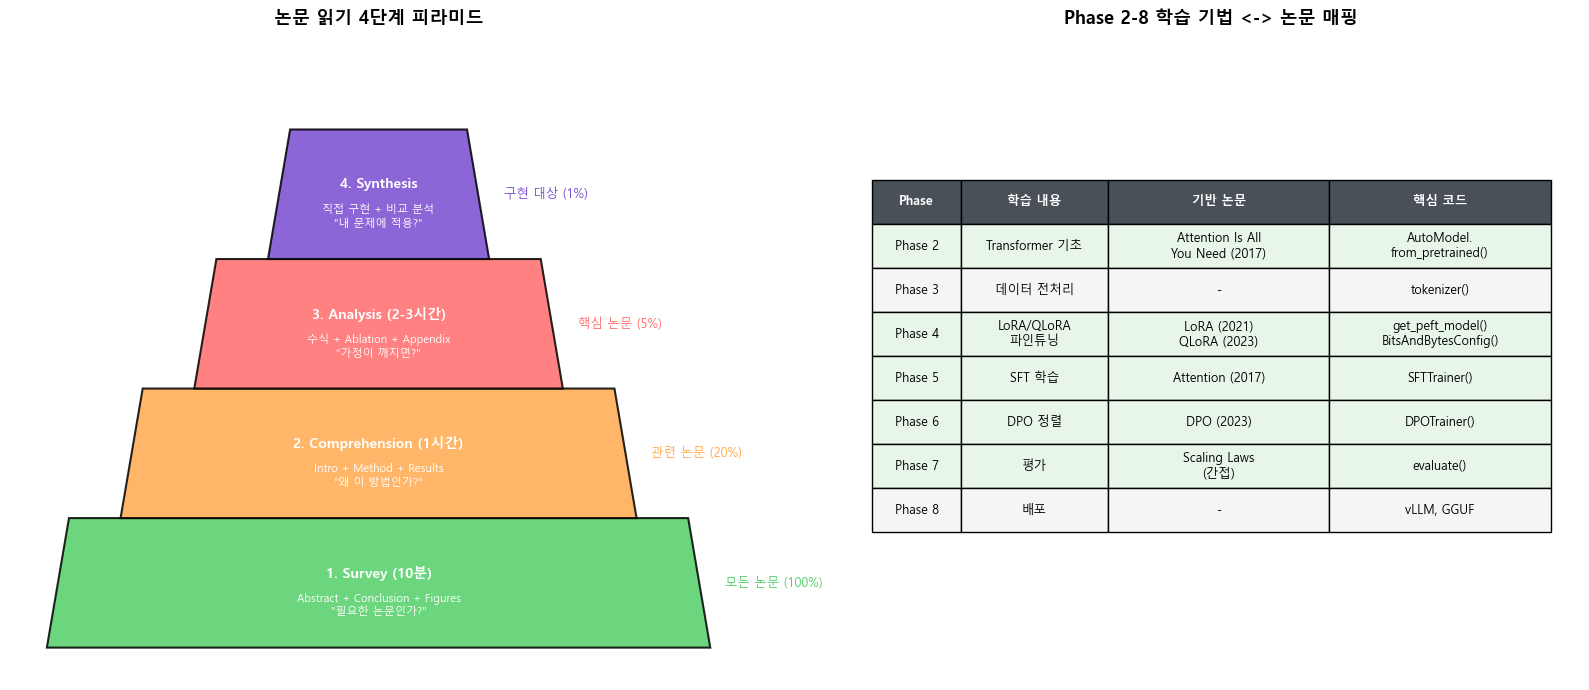


논문 읽기 핵심 팁:
  1. Survey 10분으로 80%의 논문을 걸러내라
  2. Ablation Study가 가장 중요한 섹션이다
  3. Related Work는 마지막에 읽어라 (편향 방지)
  4. 구현할 논문만 4단계까지 깊게 파라


In [9]:
# === 논문 읽기 방법론 시각화 + Phase-논문 매핑 ===

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Panel 1: 피라미드 다이어그램 (4단계) ---
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('논문 읽기 4단계 피라미드', fontsize=13, fontweight='bold')

# 피라미드 레이어 (아래가 넓고, 위가 좁음 = 걸러짐)
layers = [
    {'y': 0.5, 'h': 2.0, 'w_left': 0.5, 'w_right': 9.5,
     'color': '#51cf66', 'label': '1. Survey (10분)',
     'detail': 'Abstract + Conclusion + Figures\n"필요한 논문인가?"',
     'filter': '모든 논문 (100%)'},
    {'y': 2.5, 'h': 2.0, 'w_left': 1.5, 'w_right': 8.5,
     'color': '#ffa94d', 'label': '2. Comprehension (1시간)',
     'detail': 'Intro + Method + Results\n"왜 이 방법인가?"',
     'filter': '관련 논문 (20%)'},
    {'y': 4.5, 'h': 2.0, 'w_left': 2.5, 'w_right': 7.5,
     'color': '#ff6b6b', 'label': '3. Analysis (2-3시간)',
     'detail': '수식 + Ablation + Appendix\n"가정이 깨지면?"',
     'filter': '핵심 논문 (5%)'},
    {'y': 6.5, 'h': 2.0, 'w_left': 3.5, 'w_right': 6.5,
     'color': '#784bd1', 'label': '4. Synthesis',
     'detail': '직접 구현 + 비교 분석\n"내 문제에 적용?"',
     'filter': '구현 대상 (1%)'},
]

for layer in layers:
    # 사다리꼴 그리기
    y = layer['y']
    h = layer['h']
    shrink = 0.3  # 위쪽이 좀 더 좁음
    vertices = [
        [layer['w_left'], y],
        [layer['w_right'], y],
        [layer['w_right'] - shrink, y + h],
        [layer['w_left'] + shrink, y + h],
    ]
    polygon = plt.Polygon(vertices, facecolor=layer['color'],
                         edgecolor='black', linewidth=1.5, alpha=0.85)
    ax1.add_patch(polygon)
    
    # 라벨
    ax1.text(5, y + h/2 + 0.15, layer['label'],
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    ax1.text(5, y + h/2 - 0.35, layer['detail'],
            ha='center', va='center', fontsize=8, color='white')

# 필터링 비율 표시 (오른쪽)
for i, layer in enumerate(layers):
    ax1.text(layer['w_right'] + 0.2, layer['y'] + layer['h']/2,
            layer['filter'], fontsize=9, va='center', fontstyle='italic',
            color=layer['color'])

# --- Panel 2: Phase-논문 매핑 테이블 ---
ax2 = axes[1]
ax2.axis('off')
ax2.set_title('Phase 2-8 학습 기법 <-> 논문 매핑', fontsize=13, fontweight='bold')

# 테이블 데이터
table_data = [
    ['Phase', '학습 내용', '기반 논문', '핵심 코드'],
    ['Phase 2', 'Transformer 기초', 'Attention Is All\nYou Need (2017)', 'AutoModel.\nfrom_pretrained()'],
    ['Phase 3', '데이터 전처리', '-', 'tokenizer()'],
    ['Phase 4', 'LoRA/QLoRA\n파인튜닝', 'LoRA (2021)\nQLoRA (2023)', 'get_peft_model()\nBitsAndBytesConfig()'],
    ['Phase 5', 'SFT 학습', 'Attention (2017)', 'SFTTrainer()'],
    ['Phase 6', 'DPO 정렬', 'DPO (2023)', 'DPOTrainer()'],
    ['Phase 7', '평가', 'Scaling Laws\n(간접)', 'evaluate()'],
    ['Phase 8', '배포', '-', 'vLLM, GGUF'],
]

# 테이블 그리기
cell_colors = [['#495057'] * 4]  # 헤더
for i in range(1, len(table_data)):
    if table_data[i][2] != '-':
        cell_colors.append(['#e8f5e9'] * 4)  # 논문 연결된 Phase
    else:
        cell_colors.append(['#f5f5f5'] * 4)

table = ax2.table(cellText=table_data, cellColours=cell_colors,
                 cellLoc='center', loc='center',
                 colWidths=[0.12, 0.2, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

# 헤더 스타일
for j in range(4):
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n논문 읽기 핵심 팁:")
print("  1. Survey 10분으로 80%의 논문을 걸러내라")
print("  2. Ablation Study가 가장 중요한 섹션이다")
print("  3. Related Work는 마지막에 읽어라 (편향 방지)")
print("  4. 구현할 논문만 4단계까지 깊게 파라")

---
## 8. Phase 9 전체 핵심 정리

Phase 9의 3개 노트북에서 다룬 내용을 종합한다.

| 노트북 | 핵심 주제 | 한 줄 요약 |
|--------|----------|----------|
| **01: 최신 아키텍처** | MoE, Mamba, RoPE/YaRN/ALiBi | Transformer를 넘어서는 효율화 아키텍처들 |
| **02: 고급 학습 기법** | Continued Pre-training, Model Merging, Distillation | 기존 모델을 재활용하는 고급 기법들 |
| **03: 핵심 논문 리뷰** | 6대 논문, Scaling Laws, 논문 읽기 방법론 | 현대 LLM의 이론적 근간 이해 |

### Phase 9 핵심 원칙

> **논문을 읽는 이유는 따라하기 위해서가 아니라, 왜 그렇게 했는지 이해하기 위해서다.**  
> LoRA의 코드를 복사하는 것은 누구나 할 수 있다.  
> "가중치 변화가 저랭크 구조를 가진다"는 통찰을 이해해야 다음 문제를 스스로 풀 수 있다.

In [10]:
# === Phase 9 전체 체크포인트 ===

print("=" * 70)
print("  Phase 9 전체 체크포인트")
print("=" * 70)

checkpoints = [
    # (번호, 확인 항목, 관련 섹션)
    (1, "MoE의 Router -> Expert 선택 흐름을 그릴 수 있는가", "01: 아키텍처"),
    (2, "Transformer vs MoE vs Mamba의 핵심 차이 3가지를 말할 수 있는가", "01: 아키텍처"),
    (3, "RoPE, YaRN, ALiBi 중 상황에 맞는 것을 선택할 수 있는가", "01: 아키텍처"),
    (4, "Continued Pre-training이 필요한 상황을 판단할 수 있는가", "02: 고급 학습"),
    (5, "TIES, DARE, SLERP 중 적절한 Merging 기법을 선택할 수 있는가", "02: 고급 학습"),
    (6, "Distillation에서 Soft Label의 의미를 설명할 수 있는가", "02: 고급 학습"),
    (7, "6편 논문 각각의 핵심 기여를 한 문장으로 요약할 수 있는가", "03: 논문 리뷰"),
    (8, "Chinchilla Optimal 비율 (토큰 = 20 x 파라미터)을 적용할 수 있는가", "03: 논문 리뷰"),
    (9, "논문 읽기 4단계 방법론을 실천하고 있는가", "03: 논문 리뷰"),
    (10, "각 논문의 통찰을 실전 코드/도구와 연결할 수 있는가", "03: 논문 리뷰"),
]

print(f"\n{'#':<4} {'확인 항목':<55} {'관련 섹션':<15} {'완료'}")
print("-" * 80)
for num, item, section in checkpoints:
    print(f"{num:<4} {item:<55} {section:<15} [ ]")

print("\n" + "=" * 70)
print("  6대 논문 1문장 요약 (체크포인트 #7 참고)")
print("=" * 70)

paper_summaries = [
    ("Attention Is All You Need", "2017",
     "Self-Attention으로 순차 처리 없이 모든 위치 관계를 병렬 계산하는 Transformer를 탄생시켰다"),
    ("LoRA", "2021",
     "파인튜닝 시 가중치 변화의 저랭크 구조를 활용해 학습 파라미터를 99% 줄였다"),
    ("QLoRA", "2023",
     "NF4 양자화와 LoRA를 결합해 단일 GPU로 65B 모델 학습을 가능하게 했다"),
    ("DPO", "2023",
     "Reward Model 없이 선호도를 직접 학습하여 RLHF 파이프라인을 단순화했다"),
    ("Scaling Laws", "2020",
     "Loss가 모델/데이터/연산의 거듭제곱 함수임을 발견하고 최적 자원 배분 법칙을 제시했다"),
    ("Chain-of-Thought", "2022",
     "단계별 추론을 유도하는 프롬프트로 LLM의 잠재된 추론 능력을 해방시켰다"),
]

for name, year, summary in paper_summaries:
    print(f"\n  [{year}] {name}")
    print(f"    -> {summary}")

print("\n" + "=" * 70)
print("  Phase 9 완료. 다음: Phase 10 (종합 프로젝트)")
print("=" * 70)
print("\n핵심 원칙:")
print('  "논문을 읽는 이유는 따라하기 위해서가 아니라,')
print('   왜 그렇게 했는지 이해하기 위해서다."')

  Phase 9 전체 체크포인트

#    확인 항목                                                   관련 섹션           완료
--------------------------------------------------------------------------------
1    MoE의 Router -> Expert 선택 흐름을 그릴 수 있는가                   01: 아키텍처        [ ]
2    Transformer vs MoE vs Mamba의 핵심 차이 3가지를 말할 수 있는가        01: 아키텍처        [ ]
3    RoPE, YaRN, ALiBi 중 상황에 맞는 것을 선택할 수 있는가                 01: 아키텍처        [ ]
4    Continued Pre-training이 필요한 상황을 판단할 수 있는가               02: 고급 학습       [ ]
5    TIES, DARE, SLERP 중 적절한 Merging 기법을 선택할 수 있는가           02: 고급 학습       [ ]
6    Distillation에서 Soft Label의 의미를 설명할 수 있는가                02: 고급 학습       [ ]
7    6편 논문 각각의 핵심 기여를 한 문장으로 요약할 수 있는가                       03: 논문 리뷰       [ ]
8    Chinchilla Optimal 비율 (토큰 = 20 x 파라미터)을 적용할 수 있는가       03: 논문 리뷰       [ ]
9    논문 읽기 4단계 방법론을 실천하고 있는가                                 03: 논문 리뷰       [ ]
10   각 논문의 통찰을 실전 코드/도구와 연결할 수 있는가                           03: 논문 리뷰       [ ]

  6대 논문 